In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}

div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:40px;}
</style>
"""))

**<font size="6" color="red">ch1_허깅페이스 모델 사용하기</font>**
- Inference API 이용 : 모델의 결과를 server에서
- pipeline() 이용 : 모델을 다운로드 받아 모델의 결과를 local에서  

- 허깅페이스 transformer에서 지원하는 task

| task값| 설명 |  
| : ---| : ---  |
|text-classification(별칭 sentimentanalysis)    | 감정 분석, 뉴스 분류, 리뷰 분류 등 문장 분류|
|zero-shot-classification                      |레이블에 대한 별도 학습 없이 후보 레이블 중에서 분류|
|text-generation                               |GPT 계열 모델을 이용한 텍스트 생성|
|fill-mask                                     |문장 안의 빈칸(마스크)에 들어갈 단어 예측|
|ner (token-classification의 별칭)              |개체명 인식(사람, 조직, 장소 등 라벨링)|
|question-answering                            |주어진 지문(context)을 근거로 질문에 답변|
|summarization                                 |긴 문서를 짧게 요약|
|translation                                   |서로 다른 언어 간 번역|
|image-to-text                                 |이미지 내용을 설명하는 문장 생성|
|image-classification                          |이미지가 어떤 대상인지 분류|

- 처음 모델 사용시 "c:/Users/내컴퓨터이름/.cache/huggingface"에 다운로드되는라 시간이 걸림


In [8]:
import warnings 
import os 
import logging 
# 경고 메시지 제거 warnings.filterwarnings('ignore') 
# transformers 라이브러리의 로깅 레벨을 ERROR로 조정 (경고 숨김) logging.getLogger("transformers").setLevel(logging.ERROR) 
# Hugging Face 캐시 관련 symlink 경고 제거 
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1' 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 1. 텍스트 기반 감정분석(긍정/부정)
- 토큰화 -> 워드임베딩 -> 모델 -> predict : pipeline()함수는 이단계를 내부적으로 해 줌


In [7]:
from transformers import pipeline
classifier = pipeline(task="text-classification",
                     model ="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
classifier("I've been waiting for a Hugging face course my whole life")

C:\Users\mbc\anaconda3\envs\llm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982088804244995}]

In [8]:
from transformers import AutoModel

model = AutoModel.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")

# 전체 파라미터 개수 세기
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 66,362,880
전체 파라미터 수: 63.289MB


In [9]:
classifier = pipeline(task="sentiment-analysis",
                      model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
#감정분석할 내용이 많으면 list
classifier([
    "I've been waiting for a Hugging face course my whole life",
    "I hate this so much!"
])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982088804244995},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [9]:
classifier([
    "이 영화는 그저그러네",
    "이 영화는 그렇게 재밌지 않았지만 캐스팅이 더 별로, 근데 시간 많은사람만 봐"
])

[{'label': 'POSITIVE', 'score': 0.896101713180542},
 {'label': 'POSITIVE', 'score': 0.7968655824661255}]

In [10]:
classifier([
    "I like you",
    "힘들어요"
])

[{'label': 'POSITIVE', 'score': 0.9998695850372314},
 {'label': 'POSITIVE', 'score': 0.8669533729553223}]

In [10]:
classifier = pipeline(task="sentiment-analysis",
                      model="daekeun-ml/koelectra-small-v3-nsmc")
texts=['힘듭니다','오늘 기분 좋아', '당신이 싫지 않습니다']
classifier(texts)

Device set to use cpu


[{'label': '0', 'score': 0.99137282371521},
 {'label': '1', 'score': 0.9968572854995728},
 {'label': '1', 'score': 0.975990355014801}]

In [16]:
for text, result in zip(texts, classifier(texts)):
   label ="긍정" if result['label']=='1' else "부정"
   print(f"'{text}' -> {label} {result['score']:.2%}")
    

'힘듭니다' -> 부정 99.14%
'오늘 기분 좋아' -> 긍정 99.69%
'당신이 싫지 않습니다' -> 긍정 97.60%


## 2. 제로샷(Zero-shot-분류)
- 비지도학습
```
제로샷 분류는 기계학습 및 자연어 처리에서 개별 작업에 대한 별도의 학습(파인튜닝) 없이도 분류 작업을 수행할 수 있는 방식이다. 분류하고자 하는 후보 레이블(candidate_labels)만 지정해 주면, 모델이 사전에 학습한 언어 지식을 바탕으로 입력 문장이 어떤 레이블에 가장 가까운지 확률로 계산해 준다.
```


In [11]:
classifier =pipeline(task='zero-shot-classification',
                    model='facebook/bart-large-mnli')
classifier("I have a problem with my iphone that needs to be resolved asap!!",
          candidate_labels=['phone', 'urgent', 'tablet', 'computer'])


Device set to use cpu


{'sequence': 'I have a problem with my iphone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'tablet'],
 'scores': [0.5049771666526794,
  0.48007407784461975,
  0.012633847072720528,
  0.0023149207700043917]}

In [12]:
classifier("This is a course about the Transformer library.",
          candidate_labels=['education', 'business', 'phone'])

{'sequence': 'This is a course about the Transformer library.',
 'labels': ['education', 'business', 'phone'],
 'scores': [0.9379147291183472, 0.03584688901901245, 0.026238417252898216]}

## 3. text 생성
- gpt2 : 파라미터 갯수 124,439,808 개
- 모델 용량 : 124,439,808 * 4 => 118.675MB
- finetuning시 추가 메모리: 학습시 활성화함수, 옵티마이저, 미분, 데이터 등으로 4배 정도 메모리 필요

In [13]:
from transformers import AutoModel

model = AutoModel.from_pretrained("gpt2")

# 전체 파라미터 개수 세기
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 124,439,808
전체 파라미터 수: 118.675MB


In [17]:
generator =pipeline(task='text-generation', 
                    model="gpt2")
generator("In this course. We will teach you how to",
         pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': "In this course. We will teach you how to create an online virtual reality experience using Oculus Rift, Android and iOS.\n\nHow to Create an VR Viewing Experience with Oculus Rift:\n\nWe will teach you how to create an online virtual reality experience using Oculus Rift, Android and iOS.\n\nVirtual Reality Viewer: Virtual Reality Viewer\n\nYou'll learn how to create a virtual reality experience using Oculus Rift, Android and iOS.\n\nVirtual Reality Viewer and Controller: Virtual Reality Viewer Controller\n\nYou'll learn how to create a virtual reality experience using Oculus Rift, Android and iOS.\n\nVirtual Reality Viewer Controller and Controller: Virtual Reality Controller Controller\n\nYou'll learn how to create a virtual reality experience using Oculus Rift, Android and iOS.\n\nVirtual Reality Viewer Controller and Controller: Virtual Reality Controller Controller Controller\n\nYou'll learn how to create a virtual reality experience using Oculus Rift, Android 

In [20]:
result = generator("In this course. We will teach you how to",
         pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course. We will teach you how to work with the Arduino to create a Raspberry Pi Zero and how to use the Raspberry Pi Zero to run a simple program. We will learn how to build a Raspberry Pi Zero, how to assemble the program, and how to use the Raspberry Pi Zero software to run your programming. We will also learn how to use the Arduino and Arduino IDE to run your programming. We will learn how to develop programs and also how to program. We will build a web app for our program.

We will show you how to use the Raspberry Pi Zero to launch your program. We will explain the Arduino programming language and how to use it. We will also teach you how to use the Arduino to send and receive data. We will also teach you how to use the Arduino to control and control the program.

Next we will demonstrate how to use the Raspberry Pi Zero to run a Python program. We will show you how to build a Python program which uses the Raspberry Pi Zero and how to use the Raspberry Pi Zero software to 

In [34]:
generator =pipeline('text-generation', 
                    "skt/kogpt2-base-v2",
                   device=-1) #GPU쓰려면 0


Device set to use cpu


In [36]:
prompt='이 과정은 다음과 같은 것을 알려드려요'
result = generator(prompt, 
                   pad_token_id=generator.tokenizer.eos_token_id,
                   max_new_tokens=20,
                   do_sample=True, #샘플링 사용
                   top_k = 50,     # token의 후보 폭을 다양하게 확보
                   temperature=0.8, # activation func같이 한번더 가중치를 줌  (0.2 너무 보수적: 큰값 작은값을 확 벌어지게 / 0.9 유연한대답 : 간극을 줄임)
                   top_p = 0.9,     # 상위 90% 누적 확률 토큰만 
                   repetition_penalty=1.2   #반복적인 단어는 패널티를 부과
                  )
print(result[0]['generated_text'])       

이 과정은 다음과 같은 것을 알려드려요!"
"그렇지. 그렇다면 왜, 그 사람은 뭘 하고 있었느냐? 그리고 지금


## 4. 마스크 채우기
- fill-mask

In [39]:
unmasker = pipeline(task='fill-mask',
                   model='distilbert/distilroberta-base') # 마스크 채우기
unmasker("I'm going to hospital and meet a <mask> ", top_k=2)


Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.16069690883159637,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor "},
 {'score': 0.09552444517612457,
  'token': 9008,
  'token_str': ' nurse',
  'sequence': "I'm going to hospital and meet a nurse "}]

In [41]:
unmasker("병원에 가서 <mask>를 만날 거예요",top_k=2)  #한글 인식 안됨

[{'score': 0.6820226907730103,
  'token': 1437,
  'token_str': ' ',
  'sequence': '병원에 가서 를 만날 거예요'},
 {'score': 0.04658565670251846,
  'token': 12,
  'token_str': '-',
  'sequence': '병원에 가서-를 만날 거예요'}]

In [ ]:
# unmasker =pipeline(task='fill-mask', model='google-bert/bert-base-uncased')
# unmasker("Hello, I'm a [MASK] model.")

### inference API 이용 
- 모델의 결과를 server에게 받는것

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()
print(os.getenv('HF_TOKEN')[:2])

hf


In [12]:
from huggingface_hub import InferenceClient
client = InferenceClient(
                        provider='hf-inference',
                        api_key=os.getenv('HF_TOKEN')
                        )
result = client.fill_mask("Hello, I'm a [MASK] model.",
                         model = 'google-bert/bert-base-uncased',
                         #top_k=2
                         )
result

[FillMaskOutputElement(score=0.1441427320241928, sequence="hello, i ' m a role model.", token=2535, token_str='role', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.14175812900066376, sequence="hello, i ' m a fashion model.", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.06221463158726692, sequence="hello, i ' m a new model.", token=2047, token_str='new', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04102848470211029, sequence="hello, i ' m a super model.", token=3565, token_str='super', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.02591117098927498, sequence="hello, i ' m a business model.", token=2449, token_str='business', fill_mask_output_token_str=None)]

In [14]:
[r.sequence for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

In [21]:
# 다국어 지원되는 mask 모델
from transformers import pipeline
unmasker = pipeline("fill-mask",'google-bert/bert-base-multilingual-cased')
result=unmasker('안녕하세요. 나는 [MASK] 모델입니다')
result


Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.19656701385974884,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕하세요. 나는 가수 모델입니다'},
 {'score': 0.13671618700027466,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕하세요. 나는 여자 모델입니다'},
 {'score': 0.04897935315966606,
  'token': 102574,
  'token_str': '프로',
  'sequence': '안녕하세요. 나는 프로 모델입니다'},
 {'score': 0.03214632719755173,
  'token': 9638,
  'token_str': '이',
  'sequence': '안녕하세요. 나는 이 모델입니다'},
 {'score': 0.026808515191078186,
  'token': 100585,
  'token_str': '나는',
  'sequence': '안녕하세요. 나는 나는 모델입니다'}]

In [23]:
[r['sequence'] for r in result]

['안녕하세요. 나는 가수 모델입니다',
 '안녕하세요. 나는 여자 모델입니다',
 '안녕하세요. 나는 프로 모델입니다',
 '안녕하세요. 나는 이 모델입니다',
 '안녕하세요. 나는 나는 모델입니다']

## 5. 개체명 인식(NER; Named Entity Recognition)

In [25]:
ner = pipeline("ner",
               "dbmdz/bert-large-cased-finetuned-conll03-english",
               grouped_entities=True) # 객체들을 그룹으로 묶을지 말지
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")


Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
C:\Users\mbc\anaconda3\envs\llm\lib\site-packages\transformers\pipelines\token_classification.py:186: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="simple"` instead.
  warnings.warn(


[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

## 6. 질의응답
- context에 대한 질의 응답


In [34]:
question_answer = pipeline("question-answering")
#question-answering 타크스의 기본 모델 : distilbert/distilbert-base-cased-distilled-squad
question_answer(
            question="where do I work",
            context="My name is Sylvain and I work at Hugging Face in Brooklyn.")
# context 지문을 이용해서 답을 하는것

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'score': 0.6632858514785767, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

In [30]:
context="My name is Sylvain and I work at Hugging Face in Brooklyn."
context[33:45]

'Hugging Face'

## 7. 문서요약
- torch 버전 2.6보다 낮으면 문서요약 안될 수 있음

In [36]:
summarizer = pipeline("summarization",
                     "facebook/bart-large-cnn")
summarizer('''
Tonight, the 2026 NFL season begins with a rematch of last season's Super Bowl 60: a Seahawks 29-13 victory against the Patriots.

This marks the third time in NFL history that the season opens up following a rematch of the previous year's Super Bowl: 2016, when the Panthers lost to the defending champion Broncos 21-20 on a missed field goal, and in 1970 when the Minnesota Vikings took revenge against the Kansas City Chiefs in a 27-10 victory.

Seattle, led by their dominating defense, the "Dark Side," is coming off a pretty quiet offseason. The team lost pro-bowler cornerback Tariq Woolen to the Philadelphia Eagles and safety Coby Bryant to the Chicago Bears in free agency. Super Bowl MVP running back Kenneth Walker also departed from the team, joining the Kansas City Chiefs. Additionally, offensive coordinator Klint Kubiak joined the Oakland Raiders to become their next head coach. Despite the key losses, Seattle was able to retain a bulk of their stars from last season.

One of the big offseason winners was the Patriots, making a splash trade with the Eagles for 3x Pro-Bowler wideout A.J. Brown. Furthermore, the Pats also made some big moves in free agency, adding receiver Romeo Doubs, multi-time All-Pro safety Kevin Byard, edge rusher Dre'Mont Jones, offensive guard Alijah Vera-Tucker, and fullback Reggie Gillam.
''',max_length=130, 
          min_length=30,
          do_sample=True)


Device set to use cpu


[{'summary_text': "The 2026 NFL season begins with a rematch of last season's Super Bowl 60. This marks the third time in NFL history that the season opens up following a rematch. The Seattle Seahawks beat the New England Patriots 29-13 in the Super Bowl."}]

## 8. 번역

In [38]:
#pip install sacremoses
translator =pipeline('translation',
                    'Helsinki-NLP/opus-mt-fr-en') #프랑스어 -> 영어
translator('Ce cours est produit par Hugging Face.')

Device set to use cpu


[{'translation_text': 'This course is produced by Hugging Face.'}]

In [42]:
# 한 -> 영
ko2en=pipeline("translation",model="Helsinki-NLP/opus-mt-ko-en")
# 영 -> 한
en2ko=pipeline("translation",model="Helsinki-NLP/opus-mt-tc-big-en-ko")
ko_sentence="이 문장을 영어로 번역해 주세요"
en_sentence="I enjoy learning about AI"
#번역
print('한->영:', ko2en(ko_sentence)[0]['translation_text'])
print('영->한:', en2ko(en_sentence)[0]['translation_text'])

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8c83f99d-70df-43d7-a000-e36876c19094)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-ko-en/e42d1f41b66194e6d10512f8a27bebc1f4f5097e/config.json
Retrying in 1s [Retry 1/5].
Device set to use cpu
Device set to use cpu


한->영: Please translate this sentence into English.


In [44]:
result=ko2en([
    '안녕하세요? 즐거운 하루 보내세요',
    '내일부터는 open AI API를 나값니다',
    '결제를 위해서 직불카드 지참바랍니다.'
])
[r['translation_text'] for r in result]

['Hello? Have a good day.',
 "Starting tomorrow, we're going to go to the Open Al APl.",
 "I hope you don't have a credit card for the payment."]

## 9. 이미지 설명 생성

In [5]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests
import numpy as np
response = requests.get(url,stream=True).raw
image =Image.open(response)
#image = image.resize((150,100))
image_npy= np.array(image)
image_npy   #2차원이미지 - 흑백이미지 



array([[113, 114, 117, ...,  41,  41,  42],
       [117, 117, 118, ...,  42,  42,  41],
       [121, 121, 122, ...,  42,  41,  41],
       ...,
       [ 72,  73,  76, ...,  65,  56,  48],
       [ 71,  72,  73, ...,  62,  54,  51],
       [ 67,  69,  69, ...,  60,  51,  53]], shape=(512, 768), dtype=uint8)

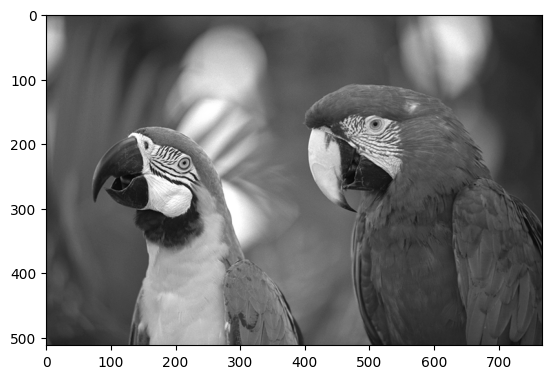

In [6]:
import matplotlib.pyplot as plt
plt.imshow(image_npy, cmap='gray')
plt.show()

In [9]:
from transformers import pipeline
imagetotext= pipeline("image-to-text",
                     "ydshieh/vit-gpt2-coco-en")
imagetotext(url, max_new_tokens=30) # 30토큰 내로 설명

Device set to use cpu


[{'generated_text': 'two birds are standing next to each other '}]

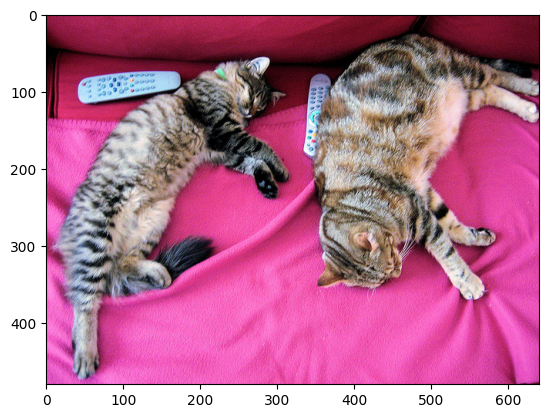

In [10]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(url,stream=True).raw
image =Image.open(response)
#image = image.resize((150,100))
image_npy= np.array(image)
image_npy   #2차원이미지 - 흑백이미지 
plt.imshow(image_npy, cmap='gray')
plt.show()

In [11]:
imagetotext= pipeline("image-to-text",
                     "ydshieh/vit-gpt2-coco-en")
imagetotext(url, max_new_tokens=300) # 30토큰 내로 설명

Device set to use cpu


[{'generated_text': 'a cat laying on a blanket next to a cat laying on a bed '}]

In [13]:
filename='images/fb.jpg'
# Image.open(filename)
imagetotext(filename, max_new_tokens=300) 

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

## 10. 이미지분류

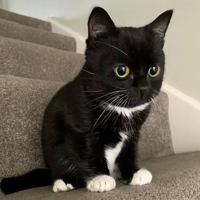

In [15]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

In [16]:
imgclassifier =pipeline("image-classification",
                       "google/vit-base-patch16-224")
imgclassifier(image)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


[{'label': 'Egyptian cat', 'score': 0.8531320691108704},
 {'label': 'tabby, tabby cat', 'score': 0.04750381037592888},
 {'label': 'tiger cat', 'score': 0.034866224974393845},
 {'label': 'Persian cat', 'score': 0.00755581958219409},
 {'label': 'Siamese cat, Siamese', 'score': 0.003788580419495702}]